In [ ]:
# Memory safety: cap this kernel to the RAM free right now so an out-of-memory
# operation fails with a clean MemoryError instead of crashing VS Code /
# thrashing swap. For very large parquet loads, read_parquet_float32() from this
# module keeps peak memory bounded.
import os, sys
sys.path.insert(0, os.path.abspath("../../../Generic-Parallel-Compute-Helper/")) ; from memory_compute import *
install_memory_guard()


In [5]:
import os
import sys
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("../../")); from EPF import variables

# Rebuild the same y_train / derived_targets / horizon_list this analysis depends on.
# Targets only (no feature matrix load) keeps this notebook's memory footprint small.

def train_valid_test_split(data):
    train = data[(data.index >= variables.TRAIN_START) & (data.index <= variables.VALID_START)]
    validate = data[(data.index > variables.VALID_START) & (data.index <= variables.TEST_START)]
    test = data[data.index > variables.TEST_START]
    return train, validate, test

y_train, y_validate, y_test = train_valid_test_split(pd.read_parquet(variables.AGG_TARGET_DATASET_PATH))

# Downstream code (and target_dfs in 1_derive_new_targets.ipynb) expect "h{h}" columns.
_rename_map = {f"target_h{h}": f"h{h}" for h in range(1, variables.HORIZON_COUNT + 1)}
y_train = y_train.rename(columns=_rename_map)
y_validate = y_validate.rename(columns=_rename_map)
y_test = y_test.rename(columns=_rename_map)

training_range = pd.date_range(
    variables.PIPELINE_START_DATE,
    variables.VALID_START,
    freq=f'{variables.FEATURE_GRANULARITY_IN_MINUTES}min'
)
chronological_weights = np.exp(np.linspace(0.0, 1.5, len(training_range))).astype(np.float32)

def _create_y_derivatives_per_target_col(horizon: int):
    """Compute all y (target) transformations for a given horizon."""

    target_col = f"h{horizon}"

    PRICE_TRANSFORM_SCALE = 100
    STANDARD_CLIP_PERCENTILE = 97.0
    POSITIVE_SPIKE_THRESHOLD = 150.0
    NEGATIVE_PRICE_THRESHOLD = 0.0
    POSITIVE_SPIKE_UPWEIGHT = 10.0
    NEGATIVE_SPIKE_UPWEIGHT = 7.0

    y_train_individual_target = y_train[target_col].values.astype(np.float32)
    y_validate_individual_target = y_validate[target_col].values.astype(np.float32)

    y_train_loss_weights = chronological_weights.astype(np.float32)
    y_train_full_range_loss_weights = (chronological_weights * np.where(y_train_individual_target > POSITIVE_SPIKE_THRESHOLD, 3.0, 1.0)).astype(np.float32)
    y_train_positive_spike_loss_weights = (chronological_weights * np.where(y_train_individual_target > POSITIVE_SPIKE_THRESHOLD, POSITIVE_SPIKE_UPWEIGHT, 1.0)).astype(np.float32)
    y_train_negative_spike_loss_weights = (chronological_weights * np.where(y_train_individual_target < NEGATIVE_PRICE_THRESHOLD, NEGATIVE_SPIKE_UPWEIGHT, 1.0)).astype(np.float32)

    y_train_individual_clipped = float(np.percentile(y_train_individual_target, STANDARD_CLIP_PERCENTILE))

    y_train_individual_clipped_transformed = np.arcsinh(np.minimum(y_train_individual_target, y_train_individual_clipped) / PRICE_TRANSFORM_SCALE).astype(np.float32)
    y_validation_individual_clipped_transformed = np.arcsinh(np.minimum(y_validate_individual_target, y_train_individual_clipped) / PRICE_TRANSFORM_SCALE).astype(np.float32)

    y_train_individual_unclipped_transformed = np.arcsinh(y_train_individual_target / PRICE_TRANSFORM_SCALE).astype(np.float32)
    y_validation_individual_unclipped_transformed = np.arcsinh(y_validate_individual_target / PRICE_TRANSFORM_SCALE).astype(np.float32)

    positive_spike_labels_train = (y_train_individual_target > POSITIVE_SPIKE_THRESHOLD).astype(np.float32)
    positive_spike_labels_validate = (y_validate_individual_target > POSITIVE_SPIKE_THRESHOLD).astype(np.float32)

    negative_spike_labels_train = (y_train_individual_target < NEGATIVE_PRICE_THRESHOLD).astype(np.float32)
    negative_spike_labels_validate = (y_validate_individual_target < NEGATIVE_PRICE_THRESHOLD).astype(np.float32)

    return {
        'y_train_individual_clipped_transformed': y_train_individual_clipped_transformed,
        'y_validation_individual_clipped_transformed': y_validation_individual_clipped_transformed,
        'y_train_individual_unclipped_transformed': y_train_individual_unclipped_transformed,
        'y_validation_individual_unclipped_transformed': y_validation_individual_unclipped_transformed,
        'positive_spike_labels_train': positive_spike_labels_train,
        'positive_spike_labels_validate': positive_spike_labels_validate,
        'negative_spike_labels_train': negative_spike_labels_train,
        'negative_spike_labels_validate': negative_spike_labels_validate,
        'y_train_loss_weights': y_train_loss_weights,
        'y_train_full_range_loss_weights': y_train_full_range_loss_weights,
        'y_train_positive_spike_loss_weights': y_train_positive_spike_loss_weights,
        'y_train_negative_spike_loss_weights': y_train_negative_spike_loss_weights
    }

horizon_list = list(range(1, variables.HORIZON_COUNT + 1))
derived_targets = {h: _create_y_derivatives_per_target_col(h) for h in horizon_list}


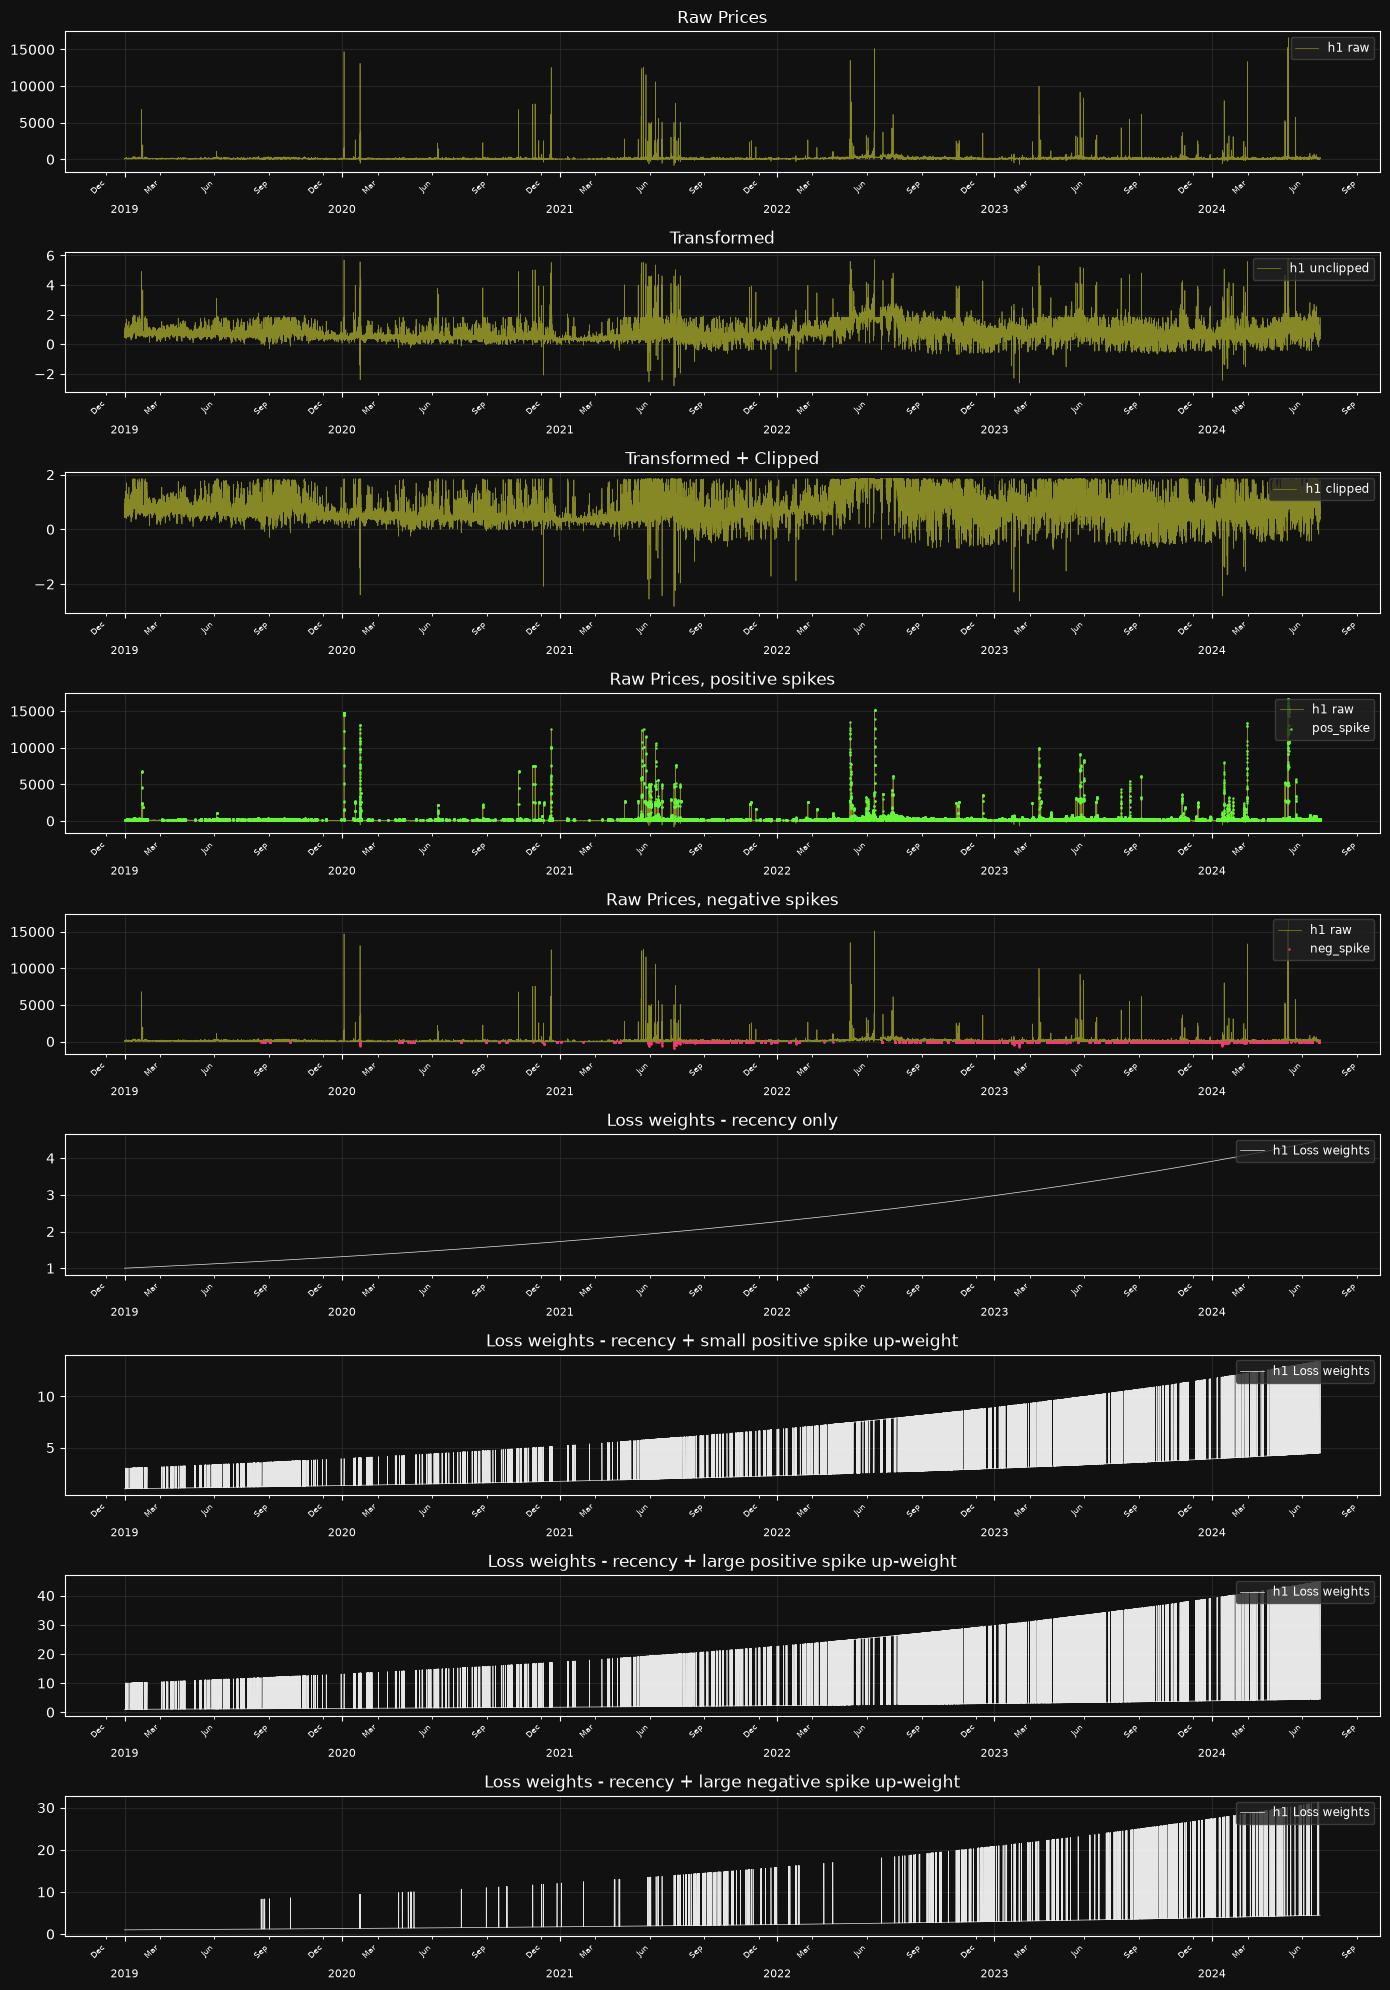

In [6]:
# Add a plotting cell to visualise derived targets for the first horizon (datetime x-axis)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

plt.style.use("dark_background")
fig, axes = plt.subplots(9, 1, figsize=(14, 20), sharex=True)
fig.patch.set_facecolor("#111111")

for ax in axes:
    ax.set_facecolor("#111111")
    ax.grid(True, color="#333333", alpha=0.6)
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")

# Only plot the first horizon
h = horizon_list[0]
d = derived_targets[h]
x = pd.to_datetime(training_range[:len(d["y_train_loss_weights"])])

axes[0].plot(
    x,
    y_train[f'h{h}'],
    color='#949628',
    alpha=0.9,
    label=f"h{h} raw",
    linewidth=0.5
)

axes[1].plot(
    x,
    d["y_train_individual_unclipped_transformed"],
    color='#949628',
    alpha=0.9,
    label=f"h{h} unclipped",
    linewidth=0.5
)

axes[2].plot(
    x,
    d["y_train_individual_clipped_transformed"],
    color='#949628',
    alpha=0.9,
    label=f"h{h} clipped",
    linewidth=0.5
)


axes[3].plot(
    x,
    y_train[f'h{h}'],
    color="#949628",
    alpha=0.9,
    label=f"h{h} raw",
    linewidth=0.5
)
pos_idx = np.where(d['positive_spike_labels_train'] == 1)[0]
axes[3].scatter(
    x[pos_idx],
    y_train[f'h{h}'].iloc[pos_idx],
    color="#65f838",
    s=0.5,
    label='pos_spike',
    zorder=5
)


axes[4].plot(
    x,
    y_train[f'h{h}'],
    color="#949628",
    alpha=0.9,
    label=f"h{h} raw",
    linewidth=0.5
)
neg_idx = np.where(d['negative_spike_labels_train'] == 1)[0]
axes[4].scatter(
    x[neg_idx],
    y_train[f'h{h}'].iloc[neg_idx],
    color="#f83872",
    s=0.5,
    label='neg_spike',
    zorder=5
)

axes[5].plot(
    x,
    d['y_train_loss_weights'],
    color="#FFFFFF",
    alpha=0.9,
    label=f"h{h} Loss weights",
    linewidth=0.5
)


axes[6].plot(
    x,
    d['y_train_full_range_loss_weights'],
    color="#FFFFFF",
    alpha=0.9,
    label=f"h{h} Loss weights",
    linewidth=0.5
)


axes[7].plot(
    x,
    d['y_train_positive_spike_loss_weights'],
    color="#FFFFFF",
    alpha=0.9,
    label=f"h{h} Loss weights",
    linewidth=0.5
)
axes[8].plot(
    x,
    d['y_train_negative_spike_loss_weights'],
    color="#FFFFFF",
    alpha=0.9,
    label=f"h{h} Loss weights",
    linewidth=0.5
)



# Year labels
for ax in axes:

    # Force labels to appear on ALL shared x-axes
    ax.tick_params(axis='x', which='both', labelbottom=True)

    # Year labels
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Optional month ticks
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))

    # Styling
    ax.tick_params(axis='x', which='major', pad=20, labelsize=8, colors='white')
    ax.tick_params(axis='x', which='minor', labelsize=6, colors='white')

    plt.setp(ax.get_xticklabels(which='major'), rotation=0)
    plt.setp(ax.get_xticklabels(which='minor'), rotation=45, ha='right')

# Add titles

axes[0].set_title("Raw Prices")
axes[1].set_title("Transformed")
axes[2].set_title("Transformed + Clipped")
axes[3].set_title("Raw Prices, positive spikes")
axes[4].set_title("Raw Prices, negative spikes")
axes[5].set_title("Loss weights - recency only")
axes[6].set_title("Loss weights - recency + small positive spike up-weight")
axes[7].set_title("Loss weights - recency + large positive spike up-weight")
axes[8].set_title("Loss weights - recency + large negative spike up-weight")
# Add legends
for ax in axes:
    ax.legend(
        fontsize="small",
        facecolor="#222222",
        edgecolor="#444444",
        labelcolor="white",
        loc="upper right"
    )


plt.tight_layout()
plt.show()

In [ ]:
# Free this kernel's memory so the next notebook has RAM to work with
# (clears data variables + returns freed heap to the OS).
release_memory()
